<a href="https://colab.research.google.com/github/kikianggreani-glitch/UTS-/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ─────────────────────────────────────────
# 1. LOAD DATA TRAINING & TESTING
# ─────────────────────────────────────────
print("=" * 60)
print("  KLASIFIKASI WINE QUALITY - RANDOM FOREST")
print("=" * 60)

df_train = pd.read_csv('https://drive.google.com/uc?id=14smuGADaoB6tTdDZ-82viYJv6uKi1LAt')
df_test  = pd.read_csv('https://drive.google.com/uc?id=1Fc2SefcyCSfYQvdIf9DJKAy6aAuD2lCM')

print(f"\n[INFO] Data Training : {df_train.shape[0]} baris, {df_train.shape[1]} kolom")
print(f"[INFO] Data Testing  : {df_test.shape[0]} baris, {df_test.shape[1]} kolom")


  KLASIFIKASI WINE QUALITY - RANDOM FOREST

[INFO] Data Training : 857 baris, 13 kolom
[INFO] Data Testing  : 286 baris, 12 kolom


In [ ]:
# ─────────────────────────────────────────
# 2. EKSPLORASI DATA TRAINING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  EKSPLORASI DATA TRAINING")
print("=" * 60)

print("\n[INFO] 5 Baris Pertama:")
print(df_train.head())

print("\n[INFO] Statistik Deskriptif:")
print(df_train.describe().round(3))

print("\n[INFO] Missing Values:")
print(df_train.isnull().sum())

print("\n[INFO] Distribusi Label (quality):")
print(df_train['quality'].value_counts().sort_index().to_string())


  EKSPLORASI DATA TRAINING

[INFO] 5 Baris Pertama:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0    

In [ ]:
# ─────────────────────────────────────────
# 3. PERSIAPAN FITUR DAN TARGET
# ─────────────────────────────────────────
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

X_train = df_train[feature_cols]
y_train = df_train['quality']
X_test  = df_test[feature_cols]
id_test = df_test['Id']

print(f"\n[INFO] Fitur digunakan : {len(feature_cols)} fitur")
print(f"[INFO] Kelas unik      : {sorted(y_train.unique())}")


[INFO] Fitur digunakan : 11 fitur
[INFO] Kelas unik      : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [ ]:
# ─────────────────────────────────────────
# CEK MISSING VALUE DATA TESTING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  CEK MISSING VALUE - DATA TESTING")
print("=" * 60)

print("\n[INFO] Missing Values pada Data Testing:")
missing_test = df_test.isnull().sum()
print(missing_test)

print(f"\n[INFO] Total missing value : {missing_test.sum()}")

if missing_test.sum() == 0:
    print("[INFO] Tidak ada missing value pada data testing. ✅")
else:
    print("[WARNING] Ditemukan missing value! Melakukan imputasi dengan median data training...")

    for col in feature_cols:
        if df_test[col].isnull().sum() > 0:
            median_val = X_train[col].median()
            df_test[col].fillna(median_val, inplace=True)
            print(f"  - Kolom '{col}' diimputasi dengan median training: {median_val:.4f}")

    # Update X_test setelah imputasi
    X_test = df_test[feature_cols]

    print("\n[INFO] Cek ulang setelah imputasi:")
    print(df_test[feature_cols].isnull().sum())
    print("[INFO] Imputasi selesai. ✅")


  CEK MISSING VALUE - DATA TESTING

[INFO] Missing Values pada Data Testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

[INFO] Total missing value : 0
[INFO] Tidak ada missing value pada data testing. ✅


In [ ]:
# ─────────────────────────────────────────
# 4. TRAINING MODEL RANDOM FOREST
#    (Random Forest tidak wajib normalisasi,
#     tapi tetap dilakukan untuk konsistensi)
# ─────────────────────────────────────────
print("\n[INFO] Melatih model Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,       # jumlah pohon
    max_depth=None,         # kedalaman maksimal pohon (None = sampai pure)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,              # gunakan semua core CPU
    class_weight='balanced' # mengatasi ketidakseimbangan kelas
)

rf_model.fit(X_train, y_train)
print("[INFO] Training selesai!")


[INFO] Melatih model Random Forest...
[INFO] Training selesai!


In [ ]:
# ─────────────────────────────────────────
# 5. EVALUASI DENGAN CROSS VALIDATION
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  EVALUASI MODEL (5-Fold Cross Validation)")
print("=" * 60)

cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    X_train, y_train, cv=5, scoring='accuracy'
)

print(f"\n  Skor tiap Fold    : {np.round(cv_scores * 100, 2)}")
print(f"  Rata-rata Akurasi : {cv_scores.mean() * 100:.2f}% ± {cv_scores.std() * 100:.2f}%")

y_train_pred = rf_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"\n  Akurasi pada Data Training : {train_acc * 100:.2f}%")
print("\n  Laporan Klasifikasi (Data Training):")
print(classification_report(y_train, y_train_pred))


  EVALUASI MODEL (5-Fold Cross Validation)

  Skor tiap Fold    : [65.12 64.53 67.25 64.33 58.48]
  Rata-rata Akurasi : 63.94% ± 2.92%

  Akurasi pada Data Training : 100.00%

  Laporan Klasifikasi (Data Training):
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



In [ ]:
# ─────────────────────────────────────────
# 6. FEATURE IMPORTANCE
# ─────────────────────────────────────────
print("=" * 60)
print("  FEATURE IMPORTANCE")
print("=" * 60)

importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)
print("\n  Peringkat Fitur (dari yang paling penting):")
for i, (feat, imp) in enumerate(importances_sorted.items(), 1):
    print(f"  {i:2}. {feat:<25} : {imp:.4f} ({imp*100:.2f}%)")

  FEATURE IMPORTANCE

  Peringkat Fitur (dari yang paling penting):
   1. volatile acidity          : 0.1559 (15.59%)
   2. alcohol                   : 0.1316 (13.16%)
   3. sulphates                 : 0.1140 (11.40%)
   4. chlorides                 : 0.0865 (8.65%)
   5. total sulfur dioxide      : 0.0856 (8.56%)
   6. density                   : 0.0820 (8.20%)
   7. citric acid               : 0.0795 (7.95%)
   8. pH                        : 0.0733 (7.33%)
   9. free sulfur dioxide       : 0.0668 (6.68%)
  10. fixed acidity             : 0.0659 (6.59%)
  11. residual sugar            : 0.0588 (5.88%)


In [ ]:
# ─────────────────────────────────────────
# 7. HYPERPARAMETER TUNING (GridSearchCV)
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 60)
print("\n[INFO] Proses tuning berjalan, harap tunggu...")

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth'   : [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10]  ,
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_cv     = grid_search.best_score_

print(f"\n  Best Parameters  : {best_params}")
print(f"  Best CV Accuracy : {best_cv * 100:.2f}%")

best_model = grid_search.best_estimator_


  HYPERPARAMETER TUNING (GridSearchCV)

[INFO] Proses tuning berjalan, harap tunggu...

  Best Parameters  : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV Accuracy : 65.10%


In [ ]:
# ─────────────────────────────────────────
# 8. PREDIKSI DATA TESTING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  PREDIKSI DATA TESTING")
print("=" * 60)

y_test_pred  = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)

df_hasil = df_test.copy()
df_hasil['predicted_quality'] = y_test_pred

for i, cls in enumerate(best_model.classes_):
    df_hasil[f'prob_quality_{cls}'] = np.round(y_test_proba[:, i], 4)

print(f"\n[INFO] Prediksi selesai untuk {len(y_test_pred)} data testing.")
print("\n[INFO] Distribusi Hasil Prediksi:")
pred_dist = pd.Series(y_test_pred).value_counts().sort_index()
for kelas, jumlah in pred_dist.items():
    print(f"  Quality {kelas} : {jumlah} data ({jumlah/len(y_test_pred)*100:.1f}%)")

print("\n[INFO] 10 Contoh Hasil Prediksi:")
print(df_hasil[['Id', 'alcohol', 'volatile acidity', 'sulphates', 'predicted_quality']].head(10).to_string(index=False))

output_csv = "hasil_prediksi_rf.csv"
df_output = df_hasil[['Id', 'predicted_quality']].rename(columns={'predicted_quality': 'Quality'})
df_output.to_csv(output_csv, index=False)
print(f"\n[INFO] Hasil prediksi disimpan ke '{output_csv}'")


  PREDIKSI DATA TESTING

[INFO] Prediksi selesai untuk 286 data testing.

[INFO] Distribusi Hasil Prediksi:
  Quality 4 : 1 data (0.3%)
  Quality 5 : 136 data (47.6%)
  Quality 6 : 118 data (41.3%)
  Quality 7 : 29 data (10.1%)
  Quality 8 : 2 data (0.7%)

[INFO] 10 Contoh Hasil Prediksi:
  Id   alcohol  volatile acidity  sulphates  predicted_quality
 222  9.500000              0.61       0.60                  5
1514  9.233333              0.84       0.72                  6
 417 10.500000              0.58       0.48                  5
 754  9.100000              0.48       1.06                  5
 516 11.900000              0.60       0.74                  6
1120 13.100000              0.54       0.72                  7
 180  9.500000              0.61       0.59                  5
  82  9.100000              0.50       0.57                  5
 632 10.500000              0.41       0.57                  6
 592  9.700000              0.45       0.57                  5

[INFO] Hasil pr

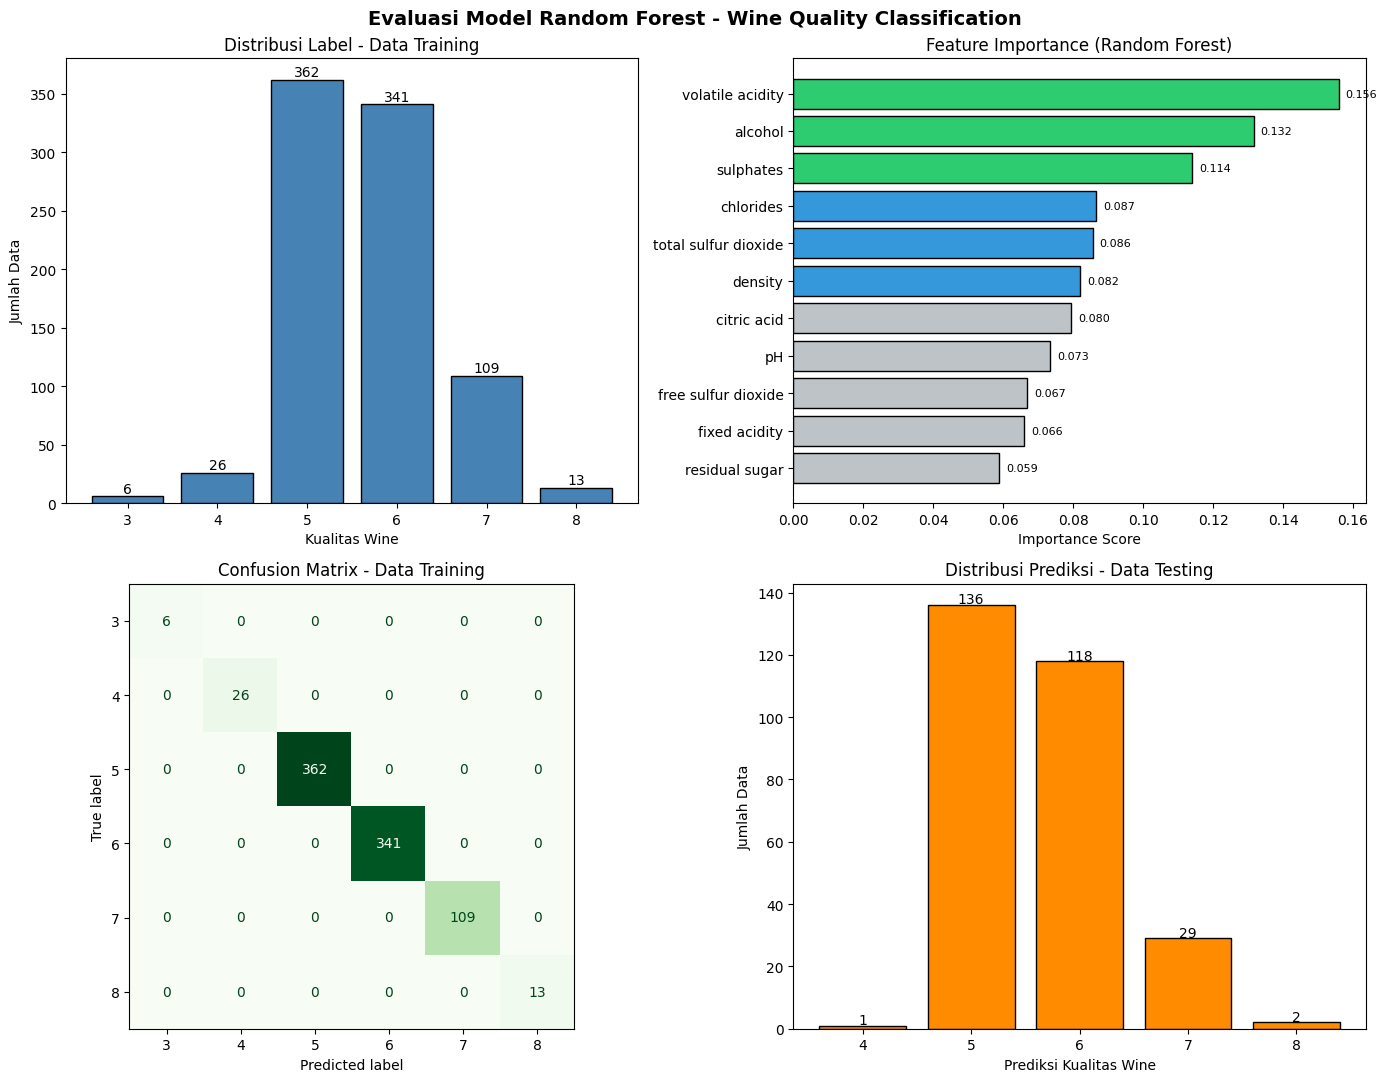


[INFO] Grafik disimpan ke 'hasil_evaluasi_rf.png'

✅ Semua proses selesai!
   - Model terbaik  : Random Forest {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
   - CV Accuracy    : 65.10%
   - File prediksi  : hasil_prediksi_rf.csv


In [ ]:
# ─────────────────────────────────────────
# 9. VISUALISASI
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Evaluasi Model Random Forest - Wine Quality Classification",
             fontsize=14, fontweight='bold')

# Plot 1: Distribusi Label Training
quality_counts = y_train.value_counts().sort_index()
bars = axes[0, 0].bar(quality_counts.index, quality_counts.values,
                       color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel("Kualitas Wine")
axes[0, 0].set_ylabel("Jumlah Data")
axes[0, 0].set_title("Distribusi Label - Data Training")
for bar, val in zip(bars, quality_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                    str(val), ha='center', fontsize=10)

# Plot 2: Feature Importance
importances_plot = importances_sorted
colors_fi = ['#2ecc71' if i < 3 else '#3498db' if i < 6 else '#bdc3c7'
             for i in range(len(importances_plot))]
axes[0, 1].barh(importances_plot.index[::-1], importances_plot.values[::-1],
                color=colors_fi[::-1], edgecolor='black')
axes[0, 1].set_xlabel("Importance Score")
axes[0, 1].set_title("Feature Importance (Random Forest)")
for i, v in enumerate(importances_plot.values[::-1]):
    axes[0, 1].text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=8)

# Plot 3: Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(ax=axes[1, 0], colorbar=False, cmap='Greens')
axes[1, 0].set_title("Confusion Matrix - Data Training")

# Plot 4: Distribusi Prediksi Testing
pred_counts = pd.Series(y_test_pred).value_counts().sort_index()
bars2 = axes[1, 1].bar(pred_counts.index, pred_counts.values,
                        color='darkorange', edgecolor='black')
axes[1, 1].set_xlabel("Prediksi Kualitas Wine")
axes[1, 1].set_ylabel("Jumlah Data")
axes[1, 1].set_title("Distribusi Prediksi - Data Testing")
for bar, val in zip(bars2, pred_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("hasil_evaluasi_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n[INFO] Grafik disimpan ke 'hasil_evaluasi_rf.png'")

print("\n✅ Semua proses selesai!")
print(f"   - Model terbaik  : Random Forest {best_params}")
print(f"   - CV Accuracy    : {best_cv * 100:.2f}%")
print(f"   - File prediksi  : {output_csv}")